# MLOPs on GCP course - MLFlow introduction

<img src=https://www.headmind.com/wp-content/uploads/2024/01/logo_dark.png width="200">

<img src=https://www.ensta-paris.fr/profiles/createur_profil/themes/createur/dist/images/logo_ensta_new.jpg.pagespeed.ce.ERsGv8BS3M.jpg width="200">

*Context*

Credit risk is the risk that a customer doesn't pay back the money they borrowed from a bank. Banks do credit risk modelling to minimize their expected credit loss. ML models can be trained to classify whether a customer is at risk or not.

*Dataset*

The German Credit Risk dataset is used.

The dataset is anonymized because it contains personal identifiable information (PII) on the bank customers. The features are described in the [dataset documentation](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data).

*Objectives*

- Dataset exploration : Using EDA, explore the relevant data 
- ML implementation : train a Random Forest Classifier with Optuna 

*Notebook made by Headmind Partners AI & Blockchain*

## Libraries

### You should have python 3.11.0 installed to run this lab and others correctly !

In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [3]:
import pickle
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import tree
import optuna
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, f1_score

from IPython.display import Image
pd.set_option("display.max_columns", 500)

c:\Users\igabay\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Running MLFlow server
MLFlow enables us to track several informations on the ML model runs through a UI. To start the server, use the command

```mlflow server --host 127.0.0.1 --port 8080```

 from the root of the project



In [4]:
import mlflow
# By default, the logs will be saved in the current folder. To link your notebook computations to the mlflow server, set the tracking uri to the same uri as the server
host = "127.0.0.1"
port = "8080"
mlflow.set_tracking_uri(uri = f"http://{host}:{port}")

## Data Exploration

In [5]:
filename = "../data/dataset.parquet"

df = pd.read_parquet(filename)
df.head()

,checking_account_status,duration_month,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence_since,property,age,other_installment_plans,housing,existing_credits_count,job,dependents_count,telephone,foreign_worker,class
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,A65,.. >= 7 years,4,male : single,none,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,A61,1 <= ... < 4 years,2,female : divorced/separated/married,none,2,real estate,22,none,own,1,skilled employee / official,1,none,yes,2
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,A61,4 <= ... < 7 years,2,male : single,none,3,real estate,49,none,own,1,unskilled - resident,2,none,yes,1
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,A61,4 <= ... < 7 years,2,male : single,guarantor,4,building society savings agreement/life insurance,45,none,for free,1,skilled employee / official,2,none,yes,1
4,< 0 DM,24,delay in paying off in the past,car (new),4870,A61,1 <= ... < 4 years,3,male : single,none,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,2


The goal is to predict if a bank can give a credit to a customer according to its profile

Question: Identify the target field

In [6]:
# Identify target field
#########################
# target_field = "..."
target_field = "class" # TODO
#########################

In [7]:
# Let's rename the target field
df = df.rename(columns={target_field:'risk'})
# And change the label values 
df['risk'] = df['risk'].map({1:0,2:1})

y = df['risk']
X = df.drop(columns=['risk'])

This is a binary classification problem where
-  y = 1 if the customer is at risk
-  y = 0 if the customer is "bankable"

In real life banks assess customer risk with more than two classes (risky or not risky).

In our case, what trick would you suggest to get n risk classes (with n>2) ? Give an example with n=4

--------------------------
ANSWER HERE

--------------------------

Binning the probabilities (For example, <0.1 very low risk, 0.2 to 0.4 low risk, 0.4 to 0.8 high risk, 0.8+ very high risk)


### Using seaborn to explore data 

Correlation matrixes and features distributions according to the credit risk are displayed using the *seaborn* library.

<Axes: >

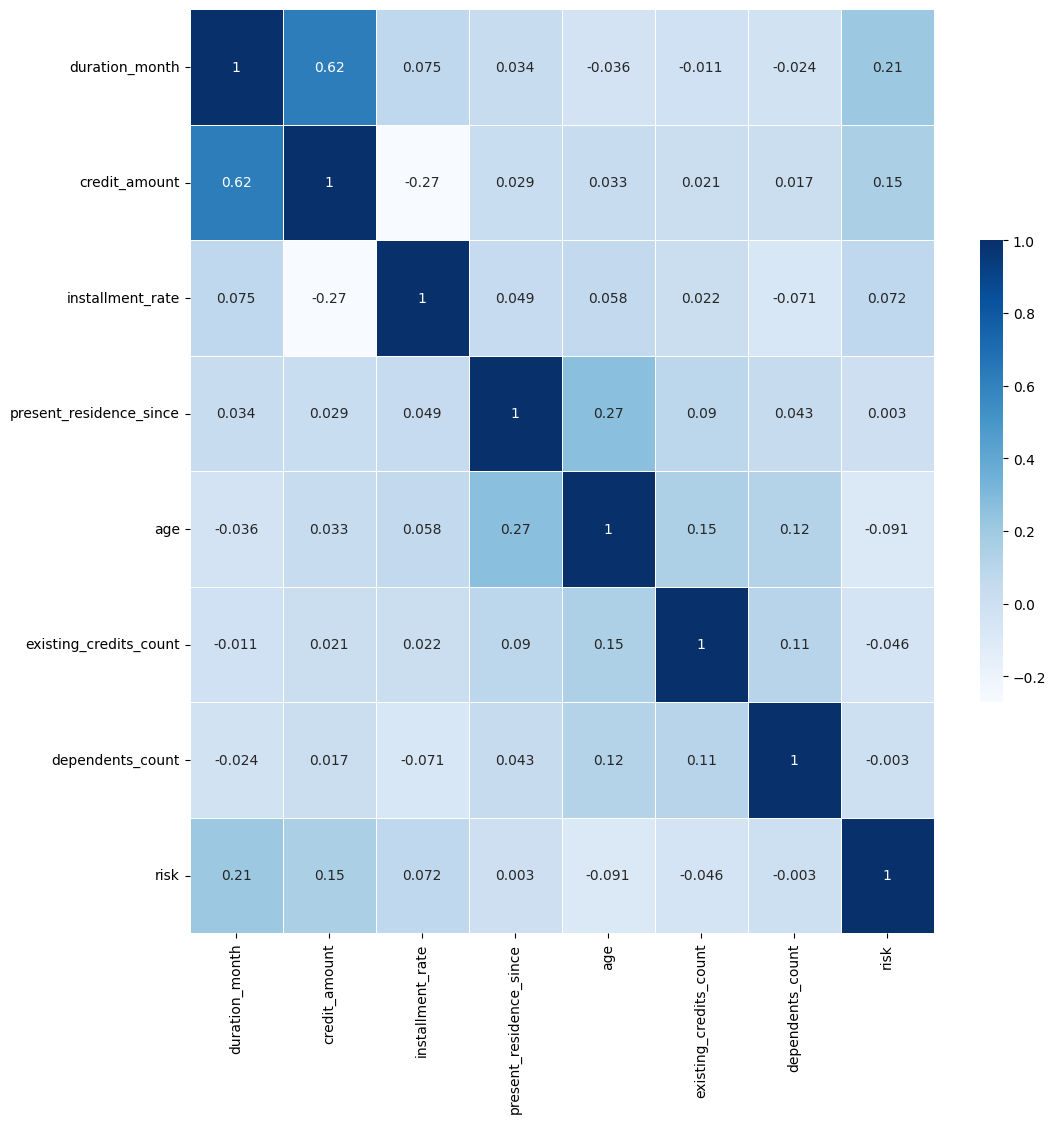

In [8]:
# Correlation matrix
corr = df.corr(numeric_only = True)
plt.figure(figsize=(12,12))
sns.heatmap(corr, cmap="Blues", annot=True, linewidths=.5, cbar_kws={"shrink": .5})


Question : Do you consider the dataset unbalanced ? Compute the label proportion. If a dataset is unbalanced what are the risks on the model? Which method would you use to manage an unbalanced dataset?

--------------------------
ANSWER HERE

--------------------------

The dataset is slightly unbalanced (0.4/0.6). If the dataset is unbalanced, then the model could be biased towards the most represented label. To manage this unbalanced dataset, you could oversample the minority data, or generate more minority data, or use a model that balances out the data during training, etc.

## Encoding

Preliminary data exploration helped us discover all the features in the dataset, their distributions and correlations.

The categorical features now have to be encoded

In [9]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
numeric_feat = X.select_dtypes(include=numerics).columns.tolist()

##############################################
# Pick the right categorical features to encode
categorical_feat = ["checking_account_status","credit_history","purpose",'savings_account',"employment_duration","personal_status_sex","other_debtors","property","other_installment_plans","housing","job","telephone","foreign_worker"] # TODO
##############################################

onehot_encoder = OneHotEncoder()

# Fit_transform - create a X_enc dataframe from the X dataframe
X_enc_array = onehot_encoder.fit_transform(X[categorical_feat])
X_enc = pd.DataFrame(X_enc_array.toarray(), columns=onehot_encoder.get_feature_names_out(input_features=categorical_feat))
X_enc[numeric_feat] = X[numeric_feat]

display(X_enc.head())


,checking_account_status_0 <= ... < 200 DM,checking_account_status_< 0 DM,checking_account_status_>= 200 DM / salary assignments for at least 1 year,checking_account_status_no checking account,credit_history_all credits at this bank paid back duly,credit_history_critical account/ other credits existing (not at this bank),credit_history_delay in paying off in the past,credit_history_existing credits paid back duly till now,credit_history_no credits taken/ all credits paid back duly,purpose_business,purpose_car (new),purpose_car (used),purpose_domestic appliances,purpose_education,purpose_furniture/equipment,purpose_others,purpose_radio/television,purpose_repairs,purpose_retraining,savings_account_A61,savings_account_A62,savings_account_A63,savings_account_A64,savings_account_A65,employment_duration_.. >= 7 years,employment_duration_... < 1 year,employment_duration_1 <= ... < 4 years,employment_duration_4 <= ... < 7 years,employment_duration_unemployed,personal_status_sex_female : divorced/separated/married,personal_status_sex_male : divorced/separated,personal_status_sex_male : married/widowed,personal_status_sex_male : single,other_debtors_co-applicant,other_debtors_guarantor,other_debtors_none,property_building society savings agreement/life insurance,"property_car or other, not in attribute 6",property_real estate,property_unknown / no property,other_installment_plans_bank,other_installment_plans_none,other_installment_plans_stores,housing_for free,housing_own,housing_rent,job_management/ self-employed/highly qualified employee/ officer,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,telephone_none,"telephone_yes, registered under the customers name",foreign_worker_no,foreign_worker_yes,duration_month,credit_amount,installment_rate,present_residence_since,age,existing_credits_count,dependents_count
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,6,1169,4,4,67,2,1
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,48,5951,2,2,22,1,1
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,12,2096,2,3,49,1,2
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,42,7882,2,4,45,1,2
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,24,4870,3,4,53,2,2


What is a one-hot encoder? How would it transform the following pandas Series: ['Cat','Cat','Dog','Cat','Bird','Dog']?

--------------------------
ANSWER HERE

--------------------------

A one-hot encoder is a method to transform a size s series that contains n unique elements into an nxs matrix with each row having a 0 in each column except the index that corresponds to the value from the original series.

[[1,0,0],[1,0,0],[0,1,0],[1,0,0],[0,0,1],[0,1,0]]

In [10]:
with open("../data/one_hot_encoder.pkl", 'wb') as file:
    pickle.dump(onehot_encoder, file)

## ML Modeling

### Train/test split

Question : Split X and y to fit the model. Make sure the risk proportion in the train set are the same as in the test set using the argument *stratify*. Use random_state = 16

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X_enc,y,test_size=0.2, stratify=y, random_state=16) # TODO

### Training an ML model
During the rest of this workshop, we'll train a random forest classifier. What other models would be appropriate for the current problem? Justify your answer.

--------------------------
ANSWER HERE

--------------------------

Since this is a classification problem on a small dataset, the following models could work (non-exhaustive): logistical regression, MLP, decision tree, a small neural network, etc.

#### Training with default hyperparameters


In [12]:
# Basic configuration

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
mlflow.set_experiment(experiment_name="finetune-creditrisk")
with mlflow.start_run(run_name="RandomForest_NoOptimization"):
    # log params
    params = rf_clf.get_params()
    mlflow.log_param("n_estimators", params["n_estimators"])
    mlflow.log_param("bootstrap", params["bootstrap"])
    mlflow.log_param("min_samples_leaf", params["min_samples_leaf"])
    mlflow.log_param("max_depth", params["max_depth"])

    # log metrics
    y_pred = rf_clf.predict_proba(X_test)[:,1]
    mlflow.log_metric("auc", roc_auc_score(y_test,y_pred))
    mlflow.log_metric("f1-score", f1_score(y_test, rf_clf.predict(X_test)))
    
    mlflow.sklearn.log_model(rf_clf, artifact_path="sklearn-model",
        registered_model_name="sk-learn-random-forest")
    
    mlflow.log_artifact(local_path='../data/one_hot_encoder.pkl', artifact_path="")

2025/05/12 10:11:32 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'sk-learn-random-forest' already exists. Creating a new version of this model...
2025/05/12 10:12:07 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: sk-learn-random-forest, version 3
Created version '3' of model 'sk-learn-random-forest'.


🏃 View run RandomForest_NoOptimization at: http://127.0.0.1:8080/#/experiments/736534708802142910/runs/4671a9a880804c5d9a763b8aa174c21c
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/736534708802142910


Using only the MLFlow UI, what are the basic parameters of a random forest classifier? (Justify by writing the path you took in the UI to read them)

--------------------------
ANSWER HERE

--------------------------

Click on finetune-creditrisk in the experiments > RandomForest_NoOptimization experiment, then it's in the parameters that you see in the overview

bootstrap
True

max_depth
None

min_samples_leaf
1

n_estimators
100


#### Optimizing hyperparameters by hand


Based on the results of the optimization, fine-tune the model using the provided code and write each result you obtain in a table

--------------------------
ANSWER HERE

--------------------------

The student should use different values that the ones provided by default and just show that they have produced different results

In [14]:
# Modify here to fine-tune the model
params = {
    "n_estimators":100,
    "bootstrap":False,
    "min_samples_leaf":1,
    "max_depth":4,
}

rf_clf = RandomForestClassifier(**params,random_state=42)
rf_clf.fit(X_train, y_train)

mlflow.set_experiment(experiment_name="finetune-creditrisk")
with mlflow.start_run(run_name="RandomForest_manualOptim"):
    # log params
    params = rf_clf.get_params()
    mlflow.log_param("n_estimators", params["n_estimators"])
    mlflow.log_param("bootstrap", params["bootstrap"])
    mlflow.log_param("min_samples_leaf", params["min_samples_leaf"])
    mlflow.log_param("max_depth", params["max_depth"])

    # log metrics
    y_pred = rf_clf.predict_proba(X_test)[:,1]
    mlflow.log_metric("auc", roc_auc_score(y_test,y_pred))
    mlflow.log_metric("f1-score", f1_score(y_test, rf_clf.predict(X_test)))
    
    mlflow.sklearn.log_model(rf_clf, artifact_path="sklearn-model",
        registered_model_name="sk-learn-random-forest")
    
    mlflow.log_artifact(local_path='../data/one_hot_encoder.pkl', artifact_path="")

2025/05/12 10:13:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'sk-learn-random-forest' already exists. Creating a new version of this model...
2025/05/12 10:13:55 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: sk-learn-random-forest, version 4
Created version '4' of model 'sk-learn-random-forest'.


🏃 View run RandomForest_manualOptim at: http://127.0.0.1:8080/#/experiments/736534708802142910/runs/3298234bb2ca40438044d5022756e0e3
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/736534708802142910


#### Optimizing hyperparameters with Optuna

<a href=https://optuna.readthedocs.io/en/stable/index.html> Optuna </a> is a hyperparameter fine-tuning framework.

To use it, you first define a trial, a scoring function, and a set of hyperparameters to fine-tune, using 'suggest' methods.

Then, you choose an heuristic and optuna will try different sets of hyperparameters and log the KPIs.

In [15]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify = y_train, random_state=16)

def objective_rf(trial):
    rf_params = {
            # Parameter space definition
            #################################################################
            'n_estimators' : trial.suggest_int('n_estimators',low=50,high=250),
            'max_depth' : trial.suggest_int('max_depth',low=2,high=10),
            'max_features' : trial.suggest_categorical('max_features', ["sqrt", None]),
            'min_samples_leaf' : trial.suggest_float("min_samples_leaf", low = 0.001, high = 0.1)
            #################################################################
            }

    rf_classifier = RandomForestClassifier(random_state=42)
    rf_classifier.set_params(**rf_params)

    rf_classifier.fit(X_train, y_train)

    # Log metrics
    y_pred = rf_classifier.predict(X_val)
    score=f1_score(y_val, y_pred)
    mlflow.log_metric("auc", roc_auc_score(y_val,y_pred))
    mlflow.log_metric("f1-score", score)
    return score

In [16]:
study = optuna.create_study(direction="maximize")
full_objective = lambda trial: objective_rf(trial)
mlflow.set_experiment(experiment_name="finetune-creditrisk")
with mlflow.start_run(run_name="RandomForest_Finetuning_exp"):
    study.optimize(full_objective, n_trials=30, timeout=600)
rf_params = study.best_trial.params

[I 2025-05-12 10:14:05,690] A new study created in memory with name: no-name-e0b316eb-9041-494a-b690-d05bc4f3a1eb
[I 2025-05-12 10:14:27,213] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 128, 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 0.05070939467596449}. Best is trial 0 with value: 0.0.
[I 2025-05-12 10:14:31,959] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 197, 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 0.06525896227917959}. Best is trial 0 with value: 0.0.
[I 2025-05-12 10:14:36,744] Trial 2 finished with value: 0.28985507246376807 and parameters: {'n_estimators': 120, 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 0.07984268052072822}. Best is trial 2 with value: 0.28985507246376807.
[I 2025-05-12 10:14:42,187] Trial 3 finished with value: 0.35616438356164387 and parameters: {'n_estimators': 140, 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 0.05519687625422774}. Best is trial 3 wi

🏃 View run RandomForest_Finetuning_exp at: http://127.0.0.1:8080/#/experiments/736534708802142910/runs/58950d65ea6e4361be7b072f7009dae9
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/736534708802142910


What is the difference between a train, validation, and test set. What are the risks if there is overlapping between the validation and test set?

--------------------------
ANSWER HERE

--------------------------

Train set: self-explanatory, set used for training

validation set: used during the hyperparameters tuning

test set: different from the validation set, is used to give a final score to the model after it has been fine-tuned.

If there is overlapping between the validation and test set, there is a risk of data leak giving a score that is not reflective of the actual performance of the model tested

In [17]:
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.set_params(**rf_params)

X_train_val, y_train_val = pd.concat((X_train, X_val)), pd.concat((y_train, y_val))

rf_classifier.fit(X_train_val, y_train_val)
with mlflow.start_run(run_name="RandomForest_Optimization"):
    # log params
    mlflow.log_param("n_estimators", rf_params["n_estimators"])
    mlflow.log_param("min_samples_leaf", rf_params["min_samples_leaf"])
    mlflow.log_param("max_depth", rf_params["max_depth"])
    mlflow.log_param('max_features', rf_params['max_features'])

    # log metrics
    y_pred = rf_classifier.predict_proba(X_test)[:,1]
    mlflow.log_metric("auc", roc_auc_score(y_test,y_pred))
    mlflow.log_metric("f1-score", f1_score(y_test, rf_classifier.predict(X_test)))
    
    mlflow.sklearn.log_model(rf_clf, artifact_path="sklearn-model",
        registered_model_name="sk-learn-random-forest-finetuned")
    mlflow.log_artifact(local_path='../data/one_hot_encoder.pkl', artifact_path="")

2025/05/12 10:17:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'sk-learn-random-forest-finetuned'.
2025/05/12 10:18:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: sk-learn-random-forest-finetuned, version 1
Created version '1' of model 'sk-learn-random-forest-finetuned'.


🏃 View run RandomForest_Optimization at: http://127.0.0.1:8080/#/experiments/736534708802142910/runs/c13b848383fa4ce5943fd991396a845a
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/736534708802142910


# Retrieves a model logged on MLFlow - on run_id

In [18]:
import mlflow
from IPython.display import display

experiment_name = ["finetune-creditrisk"]
run_name = "RandomForest_Optimization"

# Search for the run using the experiment name and run name
runs = mlflow.search_runs(experiment_names=experiment_name)

display(runs)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.f1-score,metrics.auc,params.n_estimators,params.min_samples_leaf,params.max_features,params.max_depth,params.bootstrap,tags.mlflow.log-model.history,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.name
0,c13b848383fa4ce5943fd991396a845a,736534708802142910,FINISHED,mlflow-artifacts:/736534708802142910/c13b84838...,2025-05-12 08:16:56.269000+00:00,2025-05-12 08:18:26.957000+00:00,0.563107,0.804881,249,0.0024104977490714274,None,9,None,"[{""run_id"": ""c13b848383fa4ce5943fd991396a845a""...",LOCAL,RandomForest_Optimization,igabay,c:\Users\igabay\AppData\Local\Programs\Python\...
1,58950d65ea6e4361be7b072f7009dae9,736534708802142910,FINISHED,mlflow-artifacts:/736534708802142910/58950d65e...,2025-05-12 08:14:08.862000+00:00,2025-05-12 08:16:48.687000+00:00,0.214286,0.553571,None,None,None,None,None,None,LOCAL,RandomForest_Finetuning_exp,igabay,c:\Users\igabay\AppData\Local\Programs\Python\...
2,3298234bb2ca40438044d5022756e0e3,736534708802142910,FINISHED,mlflow-artifacts:/736534708802142910/3298234bb...,2025-05-12 08:12:26.678000+00:00,2025-05-12 08:13:58.090000+00:00,0.125000,0.758214,100,1,None,4,False,"[{""run_id"": ""3298234bb2ca40438044d5022756e0e3""...",LOCAL,RandomForest_manualOptim,igabay,c:\Users\igabay\AppData\Local\Programs\Python\...
3,4671a9a880804c5d9a763b8aa174c21c,736534708802142910,FINISHED,mlflow-artifacts:/736534708802142910/4671a9a88...,2025-05-12 08:10:46.148000+00:00,2025-05-12 08:12:11.437000+00:00,0.494624,0.795000,100,1,None,None,True,"[{""run_id"": ""4671a9a880804c5d9a763b8aa174c21c""...",LOCAL,RandomForest_NoOptimization,igabay,c:\Users\igabay\AppData\Local\Programs\Python\...
4,5029bb357da74d29bd01a14e9fbddcc6,736534708802142910,RUNNING,mlflow-artifacts:/736534708802142910/5029bb357...,2025-05-12 08:08:18.471000+00:00,NaT,NaN,NaN,None,None,None,None,None,None,LOCAL,RandomForest_manualOptim,igabay,c:\Users\igabay\AppData\Local\Programs\Python\...
5,1f524d70d4f64b62ab775c17387705c0,736534708802142910,FINISHED,mlflow-artifacts:/736534708802142910/1f524d70d...,2025-05-12 08:06:37.059000+00:00,2025-05-12 08:08:08.298000+00:00,0.494624,0.795000,100,1,None,None,True,"[{""run_id"": ""1f524d70d4f64b62ab775c17387705c0""...",LOCAL,RandomForest_NoOptimization,igabay,c:\Users\igabay\AppData\Local\Programs\Python\...
6,588063d9e4dc4f65a0d834a52d075079,736534708802142910,FINISHED,mlflow-artifacts:/736534708802142910/588063d9e...,2025-05-12 07:57:59.262000+00:00,2025-05-12 07:59:23.601000+00:00,0.494624,0.795000,100,1,None,None,True,"[{""run_id"": ""588063d9e4dc4f65a0d834a52d075079""...",LOCAL,RandomForest_NoOptimization,igabay,c:\Users\igabay\AppData\Local\Programs\Python\...


In [19]:
last_run_id = runs.loc[runs["tags.mlflow.runName"] == run_name]
last_run_id.sort_values(by = ["end_time"], ascending=False, inplace=True)
run_id = last_run_id.iloc[0]["run_id"]

C:\Users\igabay\AppData\Local\Temp\ipykernel_17248\1308768644.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_run_id.sort_values(by = ["end_time"], ascending=False, inplace=True)


In [20]:
# Retrieves a model from MLFlow
model = mlflow.sklearn.load_model(f"runs:/{run_id}/sklearn-model")
model.predict(X_test)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0], dtype=int64)

# Upgrades the model status

In [21]:
from mlflow import MlflowClient

client = MlflowClient()
client.transition_model_version_stage(
    name="sk-learn-random-forest-finetuned", version=1, stage="Production"
)

C:\Users\igabay\AppData\Local\Temp\ipykernel_17248\799320548.py:4: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1747037897692, current_stage='Production', description='', last_updated_timestamp=1747037944409, name='sk-learn-random-forest-finetuned', run_id='c13b848383fa4ce5943fd991396a845a', run_link='', source='mlflow-artifacts:/736534708802142910/c13b848383fa4ce5943fd991396a845a/artifacts/sklearn-model', status='READY', status_message=None, tags={}, user_id='', version='1'>

# Retrieves the model from the status

In [22]:
import mlflow

model_name = "sk-learn-random-forest-finetuned"
model_version = 1

model = mlflow.sklearn.load_model(model_uri=f"models:/{model_name}/{model_version}")